### Központisági mértékek

Számítsa ki a közelség, közöttiség és fokszám központiságokat a korvett gráfra! 
Melyik csúcs rendelkezik a legnagyobb közelség, közöttiség, illetve fokszám központisággal?

{}

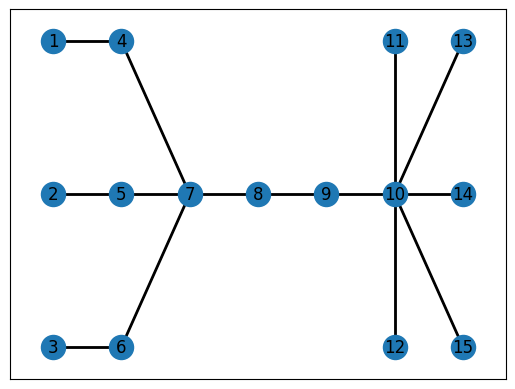

In [1]:
import networkx as nx

#Korvett gráf
G = nx.Graph()
G.add_nodes_from(range(1,16))
G.add_edge(1, 4)
G.add_edge(2, 5)
G.add_edge(3, 6)
G.add_edge(4, 7)
G.add_edge(5, 7)
G.add_edge(6, 7)
G.add_edge(7, 8)
G.add_edge(8, 9)
G.add_edge(9, 10)
G.add_edge(10, 11)
G.add_edge(10, 12)
G.add_edge(10, 13)
G.add_edge(10, 14)
G.add_edge(10, 15)

pos={1:(0,2), 2:(0,1), 3:(0,0), 4:(1,2), 5:(1,1), 6:(1,0), 7:(2,1), 8:(3,1), 9:(4,1), 10:(5,1), 11:(5,2), 12:(5,0), 13:(6,2), 14:(6,1), 15:(6,0)}

nx.draw_networkx(G, pos, with_labels = True)
nx.draw_networkx_edges(G, pos,edgelist=G.edges(data=True), width=2)
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

In [2]:
#Centralitásmutatók kiszámítása

deg = nx.degree_centrality(G)

close = nx.closeness_centrality(G)

betw = nx.betweenness_centrality(G)


temp = max(deg.values())
deg_max = [key for key in deg if deg[key] == temp]

temp = max(close.values())
close_max = [key for key in close if close[key] == temp]

temp = max(betw.values())
betw_max = [key for key in betw if betw[key] == temp]

print("legnagyobb fokszámú csúcs", deg_max)
print("legnagyobb közelség centralitású csúcs", close_max)
print("legnagyobb közöttiség centralitású csúcs", betw_max)

legnagyobb fokszámú csúcs [10]
legnagyobb közelség centralitású csúcs [8]
legnagyobb közöttiség centralitású csúcs [7]


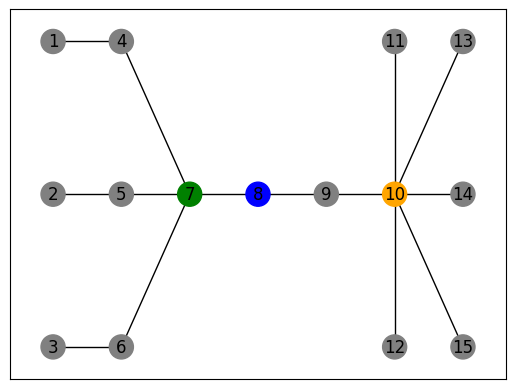

In [3]:
#Színezzük ki a legnagyobb centralitású csúcsokat

color_map = []
for node in G:
    if node == 7:
        color_map.append('green')
    elif node == 8:
        color_map.append('blue')
    elif node == 10:
        color_map.append('orange')
    else: 
        color_map.append('grey') 
nx.draw_networkx(G,pos, node_color=color_map) # node lables

Általánosságban is igaz, hogy a különféle központisági mértékek más-más csúcsokat fognak fontosnak ítélni. A felhasználó feladata eldönteni, hogy adott alkalmazás esetén melyik központiság írja le jobban a valóságot.

### Nagy hálózatok

A következő feladatban a Stanford Large Network Dataset Collection oldaláról szabadon letölthető közösségi hálózatot fogunk megvizsgálni. A hálózat csúcsai ázsiából származó Last FM felhasználókat, míg az élek kölcsönös követési kapcsolatot jelképeznek. Olvassuk be az éllistát a Networkx read_edgelist() függvényével.

In [4]:
L = nx.read_edgelist("lastfm_asia_edges.csv", nodetype=int, delimiter=";")

#A nodetype paraméterrel biztosítjuk, hogy a csúcsok számként lesznek beolvasva és nem szövegként

Hány csúcsa és hány éle van a hálózatnak?

In [5]:
print("csúcsok száma: ", len(L.nodes()))
print("élek száma: ", len(L.edges()))

csúcsok száma:  7624
élek száma:  27806


Egy ekkora hálózatot nem egyszerű ábrázolni. Érdemes a Networkx draw_networkx() függvényét megfelelően beparaméterezni. A csúcsok méretét és az élek szélességét és az alapértelmezettnél vagyük sokkal kisebbre (rendre 10 és 0.2 megteszi)! A csúcsok pozícionálására használjuk a Networkx körkörös elrendezését (lásd a dokumentációban a layout részt)  A matplotlib könyvtárral pedig növeljük meg a vászon méretét 40x40-re. (Figyelem az ábrázolás műveletigényes, az ábra elkészítése akár fél percig is eltarthat)

In [ ]:
import matplotlib.pyplot as plt 
fig = plt.figure(figsize=(40, 40)) 
pos=nx.circular_layout(L)
nx.draw_networkx(L, pos, node_size=10, width=0.2, node_color='red')

Vizsgáljuk meg a csúcsok fokszámának eloszlását! Tároljuk el a fokszámokat egy degrees nevű szótárban (dictionary), majd ábrázoljuk a matplotlib plot() függvényével az értékeket. Ezt követően rendezzük a fokszámokat csökkenő sorrendbe, majd ábrázoljuk újra.

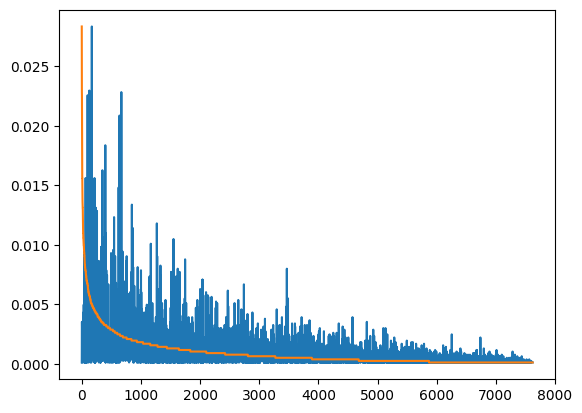

In [7]:
deg=nx.degree_centrality(L)
plt.plot(deg.values())
plt.plot(sorted(deg.values(), reverse=True))

Számoljuk ki a csúcsok PageRank értékét 0.85-ös párologtatási (damping) paraméter mellett, majd az előző feladathoz hasonlóan ábrázoljuk sorba rendezve és anélkül is.

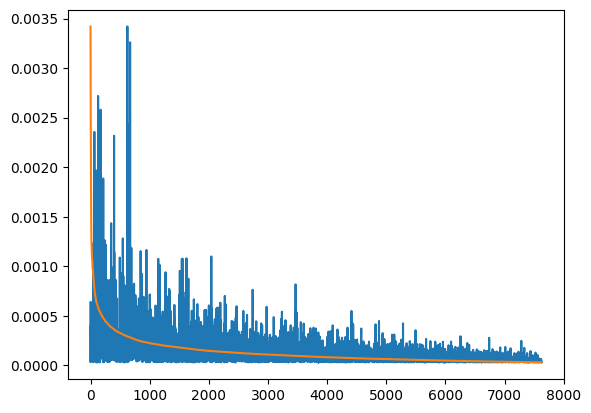

In [8]:
pr = nx.pagerank(L, alpha=0.85)
plt.clf()
plt.plot(pr.values())
plt.plot(sorted(pr.values(), reverse=True))

### Leíró statisztikák

Az alábbiakban áttekintjük a hálózatok legfontosabb leíró statisztikáit. Egy hálózat egyik legfontosabb jellemzője, hogy összefüggő-e. Például előfordulhat, hogy egy középiskolai osztály barátsági hálózata több komponensből (baráti társaságból) áll. A gráf komponenseinek (összefüggő maximális részgráfjainak) a számát egyszerűen lekérdezhetjük a number_connected_components() függvény segítségével.

In [9]:
print("A Last FM Asia komponenseinek a száma:", nx.number_connected_components(L))
if nx.number_connected_components(L) == 1:
    print("A hálózat összefüggő")

A Last FM Asia komponenseinek a száma: 1
A hálózat összefüggő


klaszterezettségi együtthatók: {0: 0.1, 1: 1.0, 2: 1.0, 3: 0, 4: 0, 5: 0}
átlagos klaszterezettség: 0.35000000000000003
kiválasztott csúcsok átlagos klaszterezettsége: 0.7000000000000001


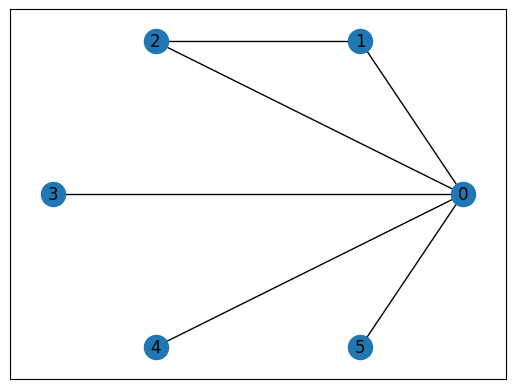

In [10]:
#Vegyünk egy csillag gráfot öt levéllel és húzzunk be egy további élt 

S = nx.star_graph(5)
S.add_edge(1,2)
pos = nx.circular_layout(S)
nx.draw_networkx(S, pos, with_labels = True)

print("klaszterezettségi együtthatók:", nx.clustering(S))

print("átlagos klaszterezettség:", nx.average_clustering(S))

some_nodes = [0,1,2]
print("kiválasztott csúcsok átlagos klaszterezettsége:", nx.average_clustering(S, nodes=some_nodes))

Öt csúcsból álló út átmérője: 4
Öt csúcsból álló út sugara: 2


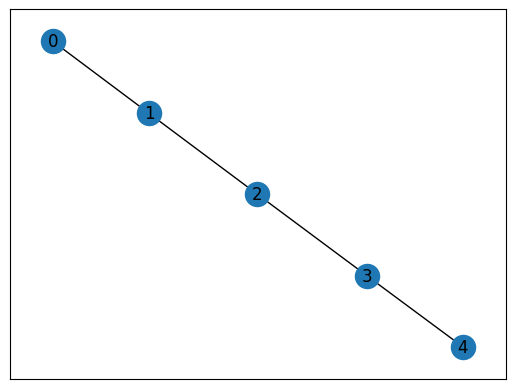

In [11]:
#Létrehozunk egy öt csúcsú utat
P = nx.path_graph(5)
pos = nx.spring_layout(P, seed=12)
nx.draw_networkx(P, pos)
print("Öt csúcsból álló út átmérője:", nx.diameter(P))
print("Öt csúcsból álló út sugara:", nx.radius(P))

In [ ]:
#A számítás nagy hálózatok esetén eltarthat egy darabig (O(nm) futásidejű). 
#Súlyozott hálózatokra is működik, ilyenkor a 'weight' paraméter beállításával 
#adhatjuk meg, hogy milyen távolságot vegyen alapul.
print("A Last FM Asia közösségi hálózat átmérője:", nx.diameter(L))
print("A Last FM Asia közösségi hálózat sugara:", nx.radius(L))

A 'small world' effektus egy közismert példája, hogy meglepően kevés 'kézfogásra' vagyunk egy híres embertől, pl. az USA elnökétől. Egy hálózat esetében ezt úgy lehet megmérni, hogy megvizsgáljuk a legrövidebb utak átlagos hosszát.

In [ ]:
#A számítás nagyobb gráfok esetében, kis időt vehet igénybe
print("A Last FM Asia közösségi hálózat rövidútjainak átlagos hossza:", nx.average_shortest_path_length(L))

### Hálózati terjedés

A Független Kaszkád egy hálózati terjedési modell. A bemenet a hálózat és egy seed halmaz. Kezdetben a csúcsokat megcímkézzük, aktív és inaktív címkékkel (seed csúcsok az aktívak, mindenki más inaktív).  A seed-re érdemes úgy tekinteni, mint néhány egyén, akinek termékmintát küldtünk egy marketing-kampány során. Tegyük fel, hogy megtetszik nekik a termék, így megpróbálják a barátaikat is meggyőzni arról, hogy vegyék meg. Az éleken lévő súly mutatja az elfogadás esélyét. Akiket meggyőznek, azok is terjeszteni kezdik a terméket. Minden frissen aktíválódott csúcsnak egyszeri esélye van meggyőzni a szomszédait. A diffúzió akkor áll le, ha nincsen több frissen aktivállódott egyén.

In [12]:
def independent_cascade(G, seed):
    import networkx as nx
    import random as rd
    
    #Ha a hálózat nem irányított, akkor azzá alakítjuk mert nem biztos, hogy minden (x,y) barátságra igaz, 
    #hogy x befolyása y-ra ugyanakkora, mint y befolyása x-re
    if nx.is_directed(G) == False:
        G=nx.to_directed(G)
    
    #Létrehozunk egy 'active' tulajdonságot minden csúcsra. 
    for i in G.nodes():
        G.nodes[i]['active']=False
    
    #Kedzetben csak a seed halmazhoz tartozó csúcsok aktívak.
    for i in seed:
        G.nodes[i]['active']=True
    
    #Minden él kap egy befolyásolási valószínűséget 1 és 10% között
    for i, j in G.edges():
        G[i][j]['propagation_prob']=rd.uniform(0.01,0.1)
    
    #Az aktív csúcsok megpróbálják befolyásolni a szomszédaikat. A sikeresen befolyásolt csúcsokon iteráljuk az eljárást.
    currently_spreading = seed.copy()
    
    #Az aktív halmazban gyűjtjük az összes csúcsot, akit sikerült aktíválni. Kezdetben ez a halmaz is a seed-del egyenlő.
    active_set = seed.copy()
    
    while len(currently_spreading) > 0:
        
        newly_activated=set()
        
        for i in currently_spreading:
            for i, j in G.out_edges(i):
                if G.nodes[j]['active']==False:
                    if rd.uniform(0,1) < G[i][j]['propagation_prob']:
                        newly_activated.add(j)
                        G.nodes[j]['active']=True
        
        currently_spreading=newly_activated
        
        #Az aktív halmazt frissítjük az újonnan aktivált csúcsokkal
        active_set.update(newly_activated)
    
    return active_set

A kérdés hogyan válasszuk meg a seed halmazt? Nyilván nem tudunk mindenkinek termékmintát küldeni. Tegyük fel, hogy 50 egyén meggyőzésére van elegendő költségkeretünk. Válasszuk ki az 50 legnagyobb fokszámú csúcsot és az 50 legnagyobb PageRank értékkel rendelkező csúcsot. Mindkét seed halmazra futtassuk le a Független Kaszkád modellt 100-szor és átlagoljuk ki, hogy hány embert sikerült aktivizálniuk. Melyik seed halmaz teljesít jobban?

In [13]:
seed_pr=set()
seed_dg=set()
sorted_pr=sorted(pr.items(), key=lambda x:x[1], reverse=True)
sorted_dg=sorted(deg.items(), key=lambda x:x[1], reverse=True)
for i in range(50):
    seed_pr.add(sorted_pr[i][0])
    seed_dg.add(sorted_dg[i][0])

In [14]:
sim_length = 100

pr_results=[]
for i in range(sim_length):
    pr_results.append(len(independent_cascade(L, seed_pr)))
print(sum(pr_results) / sim_length)

deg_results=[]
for i in range(sim_length):
    deg_results.append(len(independent_cascade(L, seed_dg)))
print(sum(deg_results) / sim_length)

697.83
668.97


Most végezzük el a szimulációt véletleneszerűen kiválasztott 50 csúccsal! Használjuk a Numpy csomag random.permutation() függvényét a csúcsok halmazára! Majd az első 50-et tegyük be egy seed halmazba.

In [15]:
import numpy as np

rand_nodes=np.random.permutation(L.nodes())
seed_rd=set()
for i in range(50):
    seed_rd.add(rand_nodes[i])

Mire számítunk? Több vagy kevesebb csúcsot fogunk elérni? Miért?

In [16]:
rd_results=[]
for i in range(sim_length):
    rd_results.append(len(independent_cascade(L, seed_rd)))
print(sum(rd_results) / sim_length)

#Kevesebb csúcsot mivel a véletlenszerűen kiválasztott csúcsok valószínűleg kevésbé központiak, így kevesebb csúcsot érnek el.

439.62


### Pagerank kiszámítása lineáris egyenletrendszerrel

Számítsuk ki a pagerank értékeket az alábbi gráfon egy lineáris program segítségével. A networkx csomaggal ellenőrizzük a számítást!

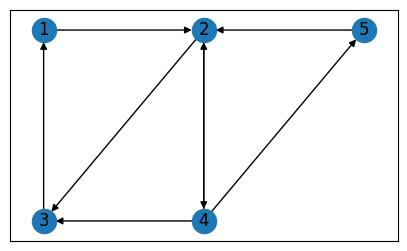

In [17]:
H=nx.DiGraph()
H.add_edge(1,2)
H.add_edge(2,3)
H.add_edge(2,4)
H.add_edge(4,2)
H.add_edge(4,3)
H.add_edge(4,5)
H.add_edge(3,1)
H.add_edge(5,2)
pos={1:(0,1), 2:(1,1), 3:(0,0), 4:(1,0), 5:(2,1)}
fig = plt.figure(figsize=(5, 3)) 
nx.draw_networkx(H, pos, with_labels=True)

Számoljuk ki a H csúcsainak PageRank értékét párologtatás nélkül!

In [18]:
nx.pagerank(H, alpha=1)

{1: 0.22222233580280365,
 2: 0.33333445766506203,
 3: 0.222221603266067,
 4: 0.16666613578025508,
 5: 0.05555546748581193}

Számoljuk ki a PageRank értékeket az előadásfólia 34. diáján látható lineáris egyenletrendszer segítségével. Ehhez szükség van a véletlen séta átmeneti mátrixának létrehozására. Induljunk ki a gráf szomszédsági mátrixából!

In [19]:
M=nx.adjacency_matrix(H)

A Numpy csomag segítségével alakítsuk egy két-dimenziós float tömbbé!

In [20]:
import numpy as np

T=M.toarray()
T=T.astype(float)

A szomszédsági mátrixból úgy lesz átmeneti mátrix, ha minden csúcsból egyenlő valószínűséggel távozunk, azaz a sorösszeg 1 kell, hogy legyen. Nyelő csúcsokból újraindítjuk a véletlen sétát, azaz ezekben a sorokban minden cellaértéket 1/n-re kell beállítani (ahol n a csúcsok száma).

In [21]:
#Minden sorban elvégezzük a normalizálást
for i in range(len(T[0])):
    rowsum=0
    #Először végigmegünk az i. soron. A rowsum változó mutatja, hogy hány ki-éle van a csúcsnak.
    for j in range(len(T[0])):
        rowsum=rowsum+T[i][j]
    
    #Ha van ki-éle a csúcsnak, akkor normalizálunk a rowsum értékkel, ha nincs akkor beállítjuk a cella értékét 1/n-re
    for j in range(len(T[0])):
        if rowsum != 0:
            T[i][j]=T[i][j]/rowsum
        else:
            T[i][j]=1/len(T[0])  

Az átmenet mátrix transzponáltjára lesz szükségünk. Erre szintén a Numpy csomag kínál megoldást.

In [22]:
T=np.transpose(T)
print(T)

[[0.         0.         1.         0.         0.        ]
 [1.         0.         0.         0.33333333 1.        ]
 [0.         0.5        0.         0.33333333 0.        ]
 [0.         0.5        0.         0.         0.        ]
 [0.         0.         0.         0.33333333 0.        ]]


Most már megpróbálkozhatunk felírni a lineáris programunkat. Mivel valójában egyenletrendszert oldunk meg, a célfüggvény bármi lehet.

In [23]:
from pulp import *
PageRank = pulp.LpProblem('PageRank', LpMaximize)
x = LpVariable.dicts('x',[i for i in range(len(T[0]))], lowBound = 0, cat="continuous")

PageRank += x[0]

for i in range(len(T[0])):
    PageRank += lpSum(T[i][j]*x[j] for j in range(len(T[0]))) + lpSum(-x[i])== 0
    
PageRank += lpSum(x[j] for j in range(len(T[0]))) == 1

megoldas = PageRank.solve()    
    
print(LpStatus[megoldas])
if LpStatus[megoldas] == 'Optimal':
    print("A csúcsok PageRank értékei")
    for i in range(len(T[0])):
        print ("x_",(i), "=", x[i].varValue)

Optimal
A csúcsok PageRank értékei
x_ 0 = 0.22222222
x_ 1 = 0.33333333
x_ 2 = 0.22222222
x_ 3 = 0.16666667
x_ 4 = 0.055555556


Most tegyük fel, hogy 20%-os párologtatást alkalmazunk.Az átmeneti mátrix minden cellájából 20% eséllyel kezdjük újra a véletlen sétát egy tetszőleges csúcsban! Alakítsuk át a T mátrixot, majd futtassuk újra a lineáris programot.

In [24]:
T=0.8*T+0.2/len(T[0])

In [25]:
from pulp import *
PageRank = pulp.LpProblem('PageRank', LpMaximize)
x = LpVariable.dicts('x',[i for i in range(len(T[0]))], lowBound = 0, cat="Continuous")

PageRank += x[0]

for i in range(len(T[0])):
    PageRank += lpSum(T[i][j]*x[j] for j in range(len(T[0]))) + lpSum(-x[i])== 0
    
PageRank += lpSum(x[j] for j in range(len(T[0]))) == 1

megoldas = PageRank.solve()    
    
print(LpStatus[megoldas])
if LpStatus[megoldas] == 'Optimal':
    print("A csúcsok PageRank értékei")
    for i in range(len(T[0])):
        print ("x_",(i), "=", x[i].varValue)

Optimal
A csúcsok PageRank értékei
x_ 0 = 0.21093716
x_ 1 = 0.32171996
x_ 2 = 0.21367144
x_ 3 = 0.16868798
x_ 4 = 0.084983462


In [26]:
nx.pagerank(H, alpha=0.8)

{1: 0.21093708357472202,
 2: 0.32171918291805657,
 3: 0.21367186675361066,
 4: 0.16868834230230711,
 5: 0.08498352445130353}

### Gráf generálás

A NetworkX modul segítségével számos klasszikus gráftípust (út, kör, csillag, teljes, stb.) tudunk egyszerű függvényhívással generálni. 

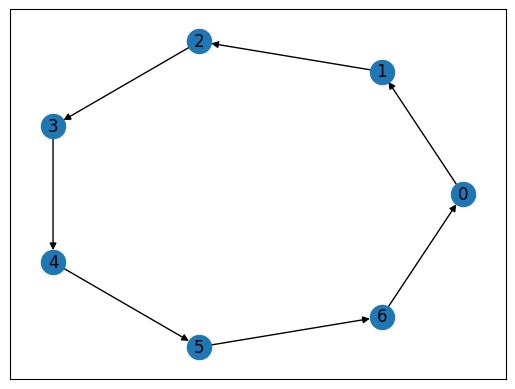

In [27]:
#Példa körgráf generálására
C = nx.cycle_graph(7, create_using=nx.DiGraph())
pos = nx.circular_layout(C)
nx.draw_networkx(C, pos)

#Az út gráf generálására már a leíró statisztikáknál volt példa

Szimulációk, vagy gráfheurisztikák tesztelése során gyakran van szükségünk mesterségesen létrehozott véletlen gráfokra. A leggyakrabban alkalmazott modellek az Erdős-Rényi véletlen gráf és Barabási Albert féle skálafüggetlen hálózatok.

- Erdős-Rényi gráf esetében meg kell adnunk a csúcsok számát $(n)$ és két csúcs közötti él létrejöttének valószínűségét $(p)$.
- A Barabási Albert gráf esetében meg kell adnunk a csúcsok számát $(n)$ és azt, hogy egy új csúcs hány korábban létrehozott csúccsal legyen összekötve $(m)$.

Mindkét modell 'seed'-elhető a reprodukálhatóság jegyében.

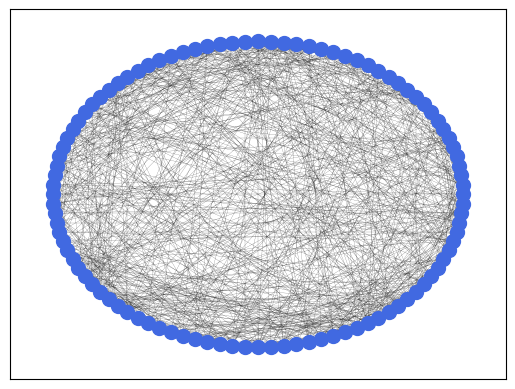

In [28]:
E = nx.erdos_renyi_graph(100, 0.15, seed=177)
pos = nx.circular_layout(E)
nx.draw_networkx(E, pos, node_size=100, width=0.1, node_color='royalblue', with_labels = False)

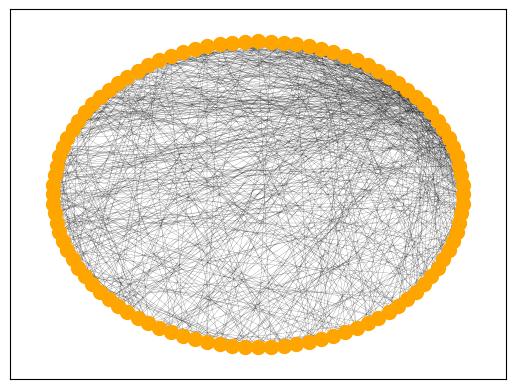

In [29]:
B = nx.barabasi_albert_graph(100, 8, seed=177)
pos = nx.circular_layout(B)
nx.draw_networkx(B, pos, node_size=100, width=0.1, node_color='orange', with_labels = False)

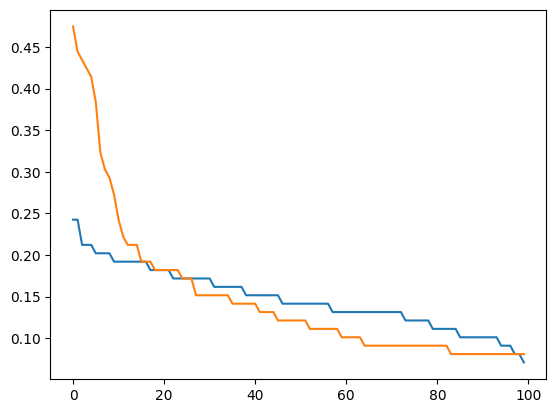

In [30]:
#Vizsgáljuk meg a fokszám eloszlást
degree = nx.degree_centrality(E)
sorted_degree = sorted(degree.values(), reverse = True)
plt.plot(sorted_degree)

degree2 = nx.degree_centrality(B)
sorted_degree2 = sorted(degree2.values(), reverse = True)
plt.plot(sorted_degree2)

#Figyeljük meg, hogy a Barabási-Albert gráf fokszám eloszlásának inverz hatványfüggvény alakja van

### Feladatok

1. Színezzük ki az Last FM Asia gráf éleit. Ha egy él mindkét csúcsának azonosító száma kisebb mint 4000, akkor legyen az él színe 'magenta', ellenkező esetben legyen a színe 'navy'.
2. Mekkorának kell válasszuk egy 110 csúcsú Erdős-Rényi gráf 'p' paraméterét, hogy várhatóan ugyanannyi élünk legyen, mint egy (n=110, m=6) paraméterekkel rendelkező Barabási-Albert gráfnak?
3. Teszteljük szimulációval, hogy egy (n=200,m=4) paraméterezéső Barabási-Albert és egy (megközelítőleg) azonos csúcs- és élszámú Erdős-Rényi hálózatok esetén melyik gráftípusban nagyobb a rövidutak átlagos hossza.
4. Irányítsuk meg a korvett gráf éleit mindkét irányba és számoljuk ki a csúcsok pagerank értékeit 0.85-ös párologtatási paraméter mellett egy LP segítségével!
5. Szimuláció segítségével vizsgáljuk meg, hogy a top 10 pagerank csúcs (alpha=0.8) melyik gráftípusban ér el több csúcsot a független kaszkád terjedési mechanizmuson keresztül, az (n=120,m=8) paraméterezésű Barabási-Albert gráf, vagy az (n=120,p=0.1254) paraméterezésű Erdős-Rényi gráf?

In [ ]:
#1. feladat megoldás
colors=[]
for u,v in L.edges():
    if u < 4000 and v < 4000:
        colors.append('magenta')
    else:
        colors.append('navy')

fig = plt.figure(figsize=(40, 40))
pos = nx.circular_layout(L)

nx.draw_networkx(L, pos, node_size=100, width=0.1, node_color='red', edge_color = colors)

In [ ]:
#2. feladat megoldás

#Egy (n=110, m=6) paraméterezésű B-A gráfnak 624 csúcsa van. Egy 120 csúcsú egyszerű gráfnak 5995 lehetséges éle van. 
#Így nagyjából p értékét 0.104-nek kell választani.

In [33]:
#3. feladat megoldás
import random as rd

sim_length = 100

barab_res = []
erdos_res = []
for i in range(sim_length):
    B = nx.barabasi_albert_graph(200, 4, seed=rd.randint(1,10000))
    E = nx.erdos_renyi_graph(200, 0.03939, seed=rd.randint(1,10000))
    if nx.is_connected(B) == False or nx.is_connected(E) == False:
        continue
    else: 
        barab_res.append(nx.average_shortest_path_length(B))
        erdos_res.append(nx.average_shortest_path_length(E))

print("Rövidutak átlagos hossza a B-A gráftípusban: ", sum(barab_res) / sim_length)
print("Rövidutak átlagos hossza az E-R gráftípusban: ", sum(erdos_res) / sim_length)



Rövidutak átlagos hossza a B-A gráftípusban:  2.5214613065326636
Rövidutak átlagos hossza az E-R gráftípusban:  2.67433216080402


In [34]:
#4. feladat megoldás
import numpy as np

G2 = G.to_directed()

M=nx.adjacency_matrix(G2)
T=M.toarray()
T=T.astype(float)
#Minden sorban elvégezzük a normalizálást
for i in range(len(T[0])):
    rowsum=0
    #Először végigmegünk az i. soron. A rowsum változó mutatja, hogy hány ki-éle van a csúcsnak.
    for j in range(len(T[0])):
        rowsum=rowsum+T[i][j]
    
    #Ha van ki-éle a csúcsnak, akkor normalizálunk a rowsum értékkel, ha nincs akkor beállítjuk a cella értékét 1/n-re
    for j in range(len(T[0])):
        if rowsum != 0:
            T[i][j]=T[i][j]/rowsum
        else:
            T[i][j]=1/len(T[0])  

T=np.transpose(T)
T=0.85*T+0.15/len(T[0])

from pulp import *
PageRank = pulp.LpProblem('PageRank', LpMaximize)
x = LpVariable.dicts('x',[i for i in range(len(T[0]))], lowBound = 0, cat="continuous")

PageRank += x[0]

for i in range(len(T[0])):
    PageRank += lpSum(T[i][j]*x[j] for j in range(len(T[0]))) + lpSum(-x[i])== 0
    
PageRank += lpSum(x[j] for j in range(len(T[0]))) == 1

megoldas = PageRank.solve()    
    
print(LpStatus[megoldas])
if LpStatus[megoldas] == 'Optimal':
    print("A csúcsok PageRank értékei")
    for i in range(len(T[0])):
        print ("x_",(i), "=", x[i].varValue)
        
print("Ellenőrzés\n", nx.pagerank(G2, alpha=0.85))

Optimal
A csúcsok PageRank értékei
x_ 0 = 0.040732965
x_ 1 = 0.040732965
x_ 2 = 0.040732965
x_ 3 = 0.072312859
x_ 4 = 0.072312859
x_ 5 = 0.072312859
x_ 6 = 0.13030512
x_ 7 = 0.0661323
x_ 8 = 0.066923439
x_ 9 = 0.20341561
x_ 10 = 0.038817211
x_ 11 = 0.038817211
x_ 12 = 0.038817211
x_ 13 = 0.038817211
x_ 14 = 0.038817211
Ellenőrzés
 {1: 0.04073319792778762, 2: 0.04073319792778762, 3: 0.04073319792778762, 4: 0.07231239214431734, 5: 0.07231239214431734, 6: 0.07231239214431734, 7: 0.13030606006555148, 8: 0.06613182245085023, 9: 0.06692392574143177, 10: 0.20341412422963587, 11: 0.038817459459243156, 12: 0.038817459459243156, 13: 0.038817459459243156, 14: 0.038817459459243156, 15: 0.038817459459243156}


In [35]:
#5. feladat megoldás

import random as rd

#szimuláció hossza (ha nem konvergál válasszuk nagyobbnak)
sim_length = 100

#ezekben tároljuk az eredményt
barab_res = []
erdos_res = []

#szimuláció kezdete
for i in range(sim_length):
    #véletlen gráfog generálása
    B = nx.barabasi_albert_graph(200, 4, seed=rd.randint(1,10000))
    E = nx.erdos_renyi_graph(200, 0.03939, seed=rd.randint(1,10000))

    #top 10 pagerank csúcs kiszámítása
    pr_b = nx.pagerank(B, alpha=0.85)
    pr_b_sorted = sorted(pr_b.items(), key = lambda item: item[1], reverse=True)
    seed_pr_b = set()
    for i in range(10):
        seed_pr_b.add(pr_b_sorted[i][0])

    pr_e = nx.pagerank(E, alpha=0.85)
    pr_e_sorted = sorted(pr_e.items(), key = lambda item: item[1], reverse=True)
    seed_pr_e = set()
    for i in range(10):
        seed_pr_e.add(pr_e_sorted[i][0])
        
    barab_res.append(len(independent_cascade(B, seed_pr_b)))
    erdos_res.append(len(independent_cascade(E, seed_pr_e)))

print("Független kaszkád átlagos nagysága a B-A gráftípusban: ", sum(barab_res) / sim_length)
print("Független kaszkád átlagos nagysága az E-R gráftípusban: ", sum(erdos_res) / sim_length)


Független kaszkád átlagos nagysága a B-A gráftípusban:  29.18
Független kaszkád átlagos nagysága az E-R gráftípusban:  20.13
